importar los archivos
estudiar los datos que contienen
asegurarte de que los tipos de datos sean correctos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Carga de datos
companies = pd.read_csv('/datasets/project_sql_result_01.csv')
neighborhoods = pd.read_csv('/datasets/project_sql_result_04.csv')

# Inspección inicial
print(companies.info())
print(neighborhoods.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None


identificar los 10 principales barrios en términos de finalización del recorrido

In [2]:
top_10_neighborhoods = neighborhoods.sort_values(by='average_trips', ascending=False).head(10)
print(top_10_neighborhoods)

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


hacer gráficos: empresas de taxis y número de viajes, los 10 barrios principales por número de finalizaciones

Empresas de Taxis y Numero de Viajes 

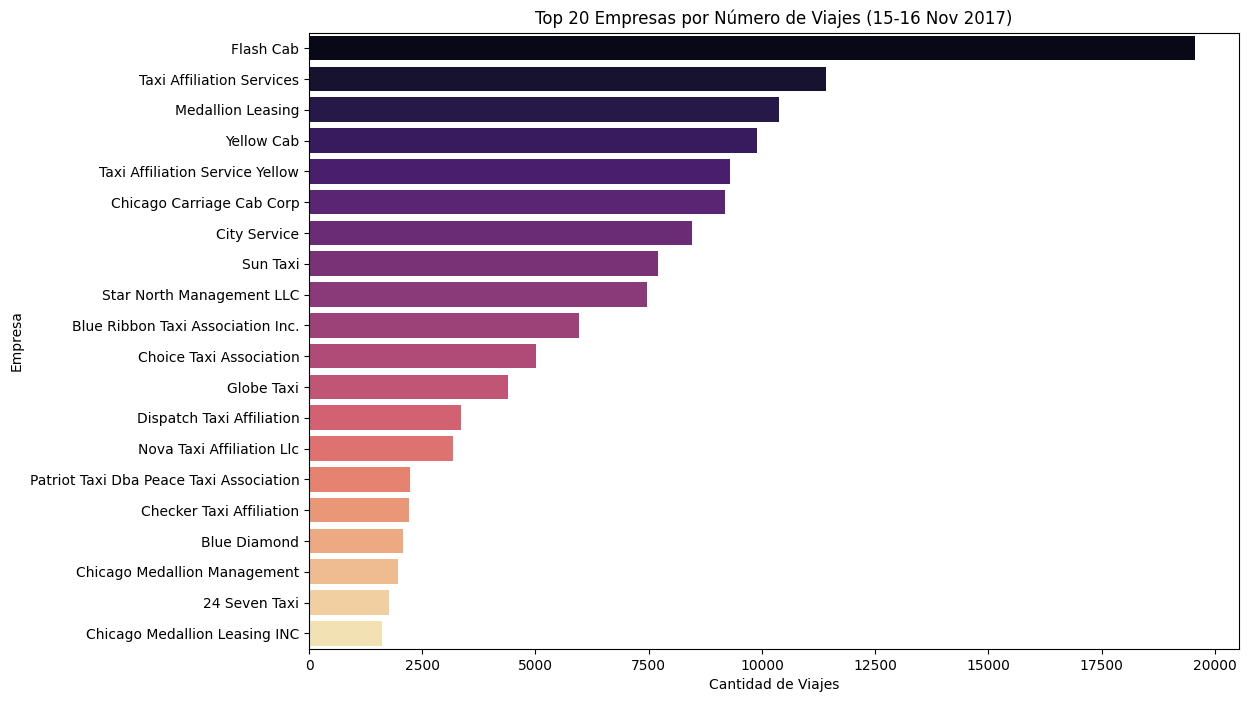

In [3]:
plt.figure(figsize=(12, 8))
sns.barplot(data=companies.sort_values(by='trips_amount', ascending=False).head(20), 
            x='trips_amount', y='company_name', palette='magma')
plt.title('Top 20 Empresas por Número de Viajes (15-16 Nov 2017)')
plt.xlabel('Cantidad de Viajes')
plt.ylabel('Empresa')
plt.show()

Top 10 barrios por finalización de viajes

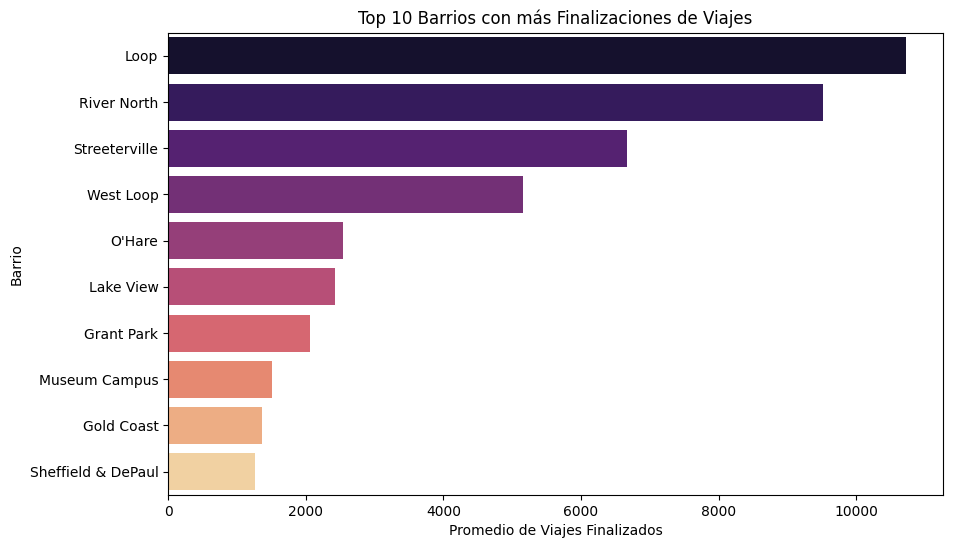

In [6]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_neighborhoods, x='average_trips', y='dropoff_location_name', palette='magma')
plt.title('Top 10 Barrios con más Finalizaciones de Viajes')
plt.xlabel('Promedio de Viajes Finalizados')
plt.ylabel('Barrio')
plt.show()

Conclusiones:
Flash Cab o Taxi Affiliation Services tienen un claro dominio en el servicio de Taxis 

Barrios como Loop y River North son los que mas hacen uso del servicio superando a muchos como O'Hare

Paso 5. Prueba de Hipótesis

Hipótesis: "La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos".
1. Planteamiento de HipótesisHipótesis Nula H0: La duración promedio de los viajes desde el Loop al Aeropuerto O'Hare es igual en los sábados lluviosos y los sábados no lluviosos.
   H0: mu lluvia =  μ despejado
   Hipótesis Alternativa H_1: La duración promedio de los viajes cambia (es diferente) cuando llueve los sábados.
   H1: μ lluvia =  μ despejado
2. Criterio de Prueba
   Utilizaremos una Prueba t de Student para dos muestras independientes, ya que comparamos las medias de dos grupos distintos (Sábados con "Bad" weather vs. "Good" weather).
   Nivel de significancia ( α ): Establecemos  α  = 0.05. Esto significa que estamos dispuestos a aceptar un 5% de riesgo de concluir que existe una diferencia cuando en realidad no la hay.

In [10]:
# Cargar datos de la prueba
trips_weather = pd.read_csv('/datasets/project_sql_result_07.csv')

# Crear dos datasets basados en la condición climática
rainy_saturdays = trips_weather[trips_weather['weather_conditions'] == 'Bad']['duration_seconds']
good_saturdays = trips_weather[trips_weather['weather_conditions'] == 'Good']['duration_seconds']

# Realizar la prueba t
results = stats.ttest_ind(rainy_saturdays, good_saturdays, equal_var=True)

print('p-value:', results.pvalue)

if results.pvalue < 0.05:
    print("Rechazamos la hipótesis nula: Hay una diferencia significativa en la duración.")
else:
    print("No podemos rechazar la hipótesis nula: No hay evidencia de diferencia significativa.")

p-value: 6.517970327099473e-12
Rechazamos la hipótesis nula: Hay una diferencia significativa en la duración.


Por qué se uso prueba t Student?, porque estamos comparando las medias de dos poblaciones distintas (viajes con clima "Good" vs. "Bad") y queremos saber si la diferencia observada es estadísticamente significativa o fruto del azar.
Nivel de significancia ( α ): He seleccionado 0.05 (5%). Es el estándar en análisis de datos; balancea bien el riesgo de cometer errores de Tipo I y Tipo II.